<a href="https://colab.research.google.com/github/vincent-chen09/MG-Gravitational-waves/blob/main/GW190425_Parameter_Estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install gwpy
%pip install lalsuite
%pip install bilby

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.5/315.5 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.6/128.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 65.3 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have cryptography 45.0.6 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 45.0.6 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bilby
from bilby.core.prior import Uniform
from gwpy.timeseries import TimeSeries
from gwpy.signal import filter_design
from gwosc import datasets
logger = bilby.core.utils.logger
outdir = "/content/drive/My Drive/Results_GW190425/"


label = "GW190425"

H1 = bilby.gw.detector.get_empty_interferometer("H1")
L1 = bilby.gw.detector.get_empty_interferometer("L1")

/usr/local/lib/python3.11/dist-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


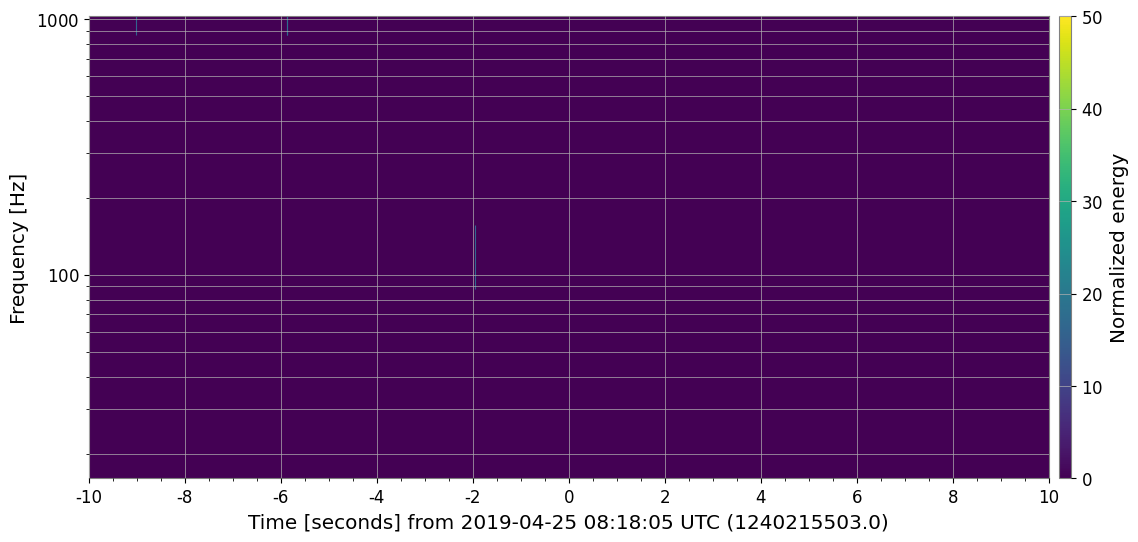

In [ ]:
gps = datasets.event_gps('GW190425')
data = TimeSeries.fetch_open_data('L1', gps-34, gps+34)
from gwpy.segments import Segment
qgram = data.q_gram(
    qrange=(4, 150),
    search=Segment(gps-10, gps+10),
    mismatch=0.35,
)
plot = qgram.tile(
    'time',
    'frequency',
    'duration',
    'bandwidth',
    color='energy',
)
ax = plot.gca()
ax.set_xscale('seconds')
ax.set_xlim(gps-10, gps+10)
ax.set_epoch(gps)
ax.set_yscale('log')
ax.set_ylim(16, 1024)
ax.set_ylabel('Frequency [Hz]')
ax.grid(True, axis='y', which='both')
from matplotlib import colormaps
cmap = colormaps['viridis']
ax.colorbar(cmap=cmap.name, label='Normalized energy', clim=[0, 50])
ax.set_facecolor(cmap(0))  # colour background to the bottom of the map
plot.show()

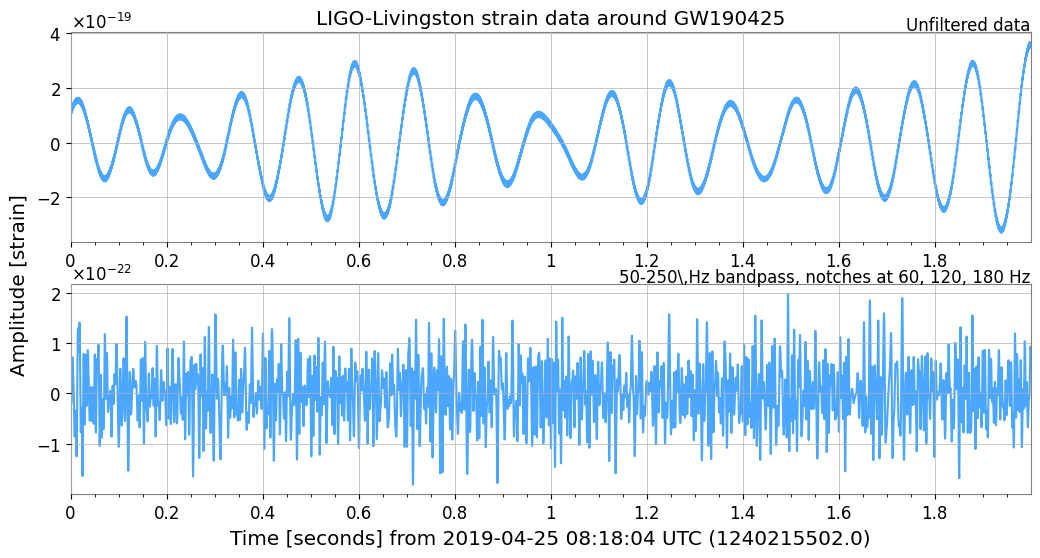

In [ ]:

event_start_time = 1240215503      # event GPS time at which GW was discovered
post_event = 2                  # time after event
pre_event = 2                 # time before event
duration = pre_event + post_event  # total time range containing event
analysis_begin = event_start_time - pre_event

L1_data = TimeSeries.fetch_open_data("L1", analysis_begin,
                                     analysis_begin + duration,
                                     sample_rate=4096, cache=True)
bp = filter_design.bandpass(50, 250, L1_data.sample_rate)
notches = [filter_design.notch(line, L1_data.sample_rate) for
           line in ( 60, 120, 180,300, 500,600, 900, 1000, 1500)]
zpk = filter_design.concatenate_zpks(bp, *notches)
lfilt = L1_data.filter(zpk, filtfilt=True)
ldata = L1_data.crop(*L1_data.span.contract(1))
lfilt = lfilt.crop(*lfilt.span.contract(1))
from gwpy.plot import Plot
plot = Plot(ldata, lfilt, figsize=[12, 6], separate=True, sharex=True,
            color='gwpy:ligo-livingston')
ax1, ax2 = plot.axes
ax1.set_title('LIGO-Livingston strain data around GW190425')
ax1.text(1.0, 1.01, 'Unfiltered data', transform=ax1.transAxes, ha='right')
ax1.set_ylabel('Amplitude [strain]', y=-0.2)
ax2.set_ylabel('')
ax2.text(1.0, 1.01, r'50-250\,Hz bandpass, notches at 60, 120, 180 Hz',
         transform=ax2.transAxes, ha='right')
plot.show()


In [ ]:
print(duration)

In [ ]:

L1.set_strain_data_from_gwpy_timeseries(L1_data)

In [ ]:
# duration typically multiplied by 32 for psd
psd_duration = duration * 32
psd_begin = analysis_begin - psd_duration

# fetch data for psd
#H1psd = TimeSeries.fetch_open_data(
    #"H1", psd_begin, psd_begin + psd_duration,
    #sample_rate=4096, cache=True)
L1psd = TimeSeries.fetch_open_data(
    "L1", psd_begin, psd_begin + psd_duration,
    sample_rate=4096, cache=True)

# set interferometers with psd data
psd_alpha = 2 * H1.strain_data.roll_off / duration
#H1psd_data = H1psd.psd(fftlength=duration, overlap=0, window=("tukey", psd_alpha), method="median")
L1psd_data = L1psd.psd(fftlength=duration, overlap=0, window=("tukey", psd_alpha), method="median")
#H1.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
    #frequency_array=H1psd_data.frequencies.value, psd_array=H1psd_data.value)
L1.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
    frequency_array=L1psd_data.frequencies.value, psd_array=L1psd_data.value)

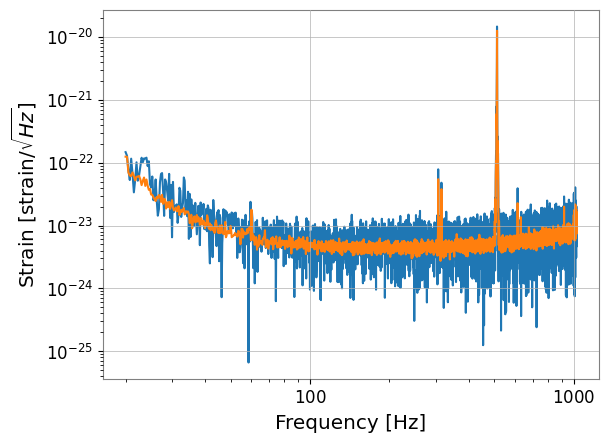

In [ ]:
#H1.maximum_frequency = 1024
L1.maximum_frequency = 1024

plt.figure()
idxs = L1.strain_data.frequency_mask
a,b = list(L1.strain_data.frequency_array[idxs]),list(np.abs(L1.strain_data.frequency_domain_strain[idxs]))
c,d = list(L1.power_spectral_density.frequency_array[idxs]),list(L1.power_spectral_density.asd_array[idxs])
plt.plot(a,b)
plt.plot(c,d)
plt.yscale('log')
plt.xscale('log')
plt.xlabel("Frequency [Hz]")
plt.ylabel("Strain [strain/$\sqrt{Hz}$]")
plt.savefig("strainvfreq")


In [ ]:
prior = bilby.core.prior.PriorDict()
# uniform priors for variable parameters
#prior['chirp_mass'] = Uniform(name='chirp_mass', minimum=10.0,maximum=100.0)
#prior['mass_ratio'] = Uniform(name='mass_ratio', minimum=0.5, maximum=1)
#prior['phase'] = Uniform(name="phase", minimum=0, maximum=2*np.pi)
#prior['geocent_time'] = Uniform(name="geocent_time", minimum=event_start_time-2,
                                #maximum=event_start_time+2)
#prior['dec'] =  Uniform(name='dec', minimum=-np.pi,maximum=np.pi) #declination
#prior['ra'] =  Uniform(name='ra', minimum=0,maximum=2*np.pi)  #right ascension
#prior['theta_jn'] =  0.6  #angles between line of sight and plane
#prior['psi'] =  Uniform(name='psi', minimum=0,maximum=2*np.pi) #polarization angle of wave
#prior['luminosity_distance'] = Uniform(name="luminosity_distance", minimum =200, maximum = 600)
# fixed values for all other parameters
prior['a_1'] =  Uniform(name='a_1', minimum=0.01,maximum=0.99)
prior['a_2'] =  Uniform(name='a_2', minimum=0.01,maximum=0.99)
prior['tilt_1'] =  0.0
prior['tilt_2'] =  0.0
prior['phi_12'] =  0.0
prior['phi_jl'] =  0.0
#prior['phase'] = 0.001
prior['dec'] =  0.5 #declination
prior['ra'] =  2.5  #right ascension
prior['theta_jn'] =  1.2 #angles between line of sight and plane
prior['psi'] =  0.9 #polarization angle of wave
prior['mass_ratio'] = 0.62
prior['phase'] = 2
prior['luminosity_distance'] = 159
prior['chirp_mass'] = 1.44
prior['geocent_time'] = 1240215503
interferometers = [L1]

waveform_arguments = dict(waveform_approximant='IMRPhenomPv2', reference_frequency=50., minimum_frequency=20.)

# set sampling frequency of data
sampling_frequency = 2048.

# generate waveforms
waveform_generator = bilby.gw.WaveformGenerator(duration=duration,
                                                sampling_frequency=sampling_frequency,
                                                frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
                                                parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
                                                waveform_arguments=waveform_arguments)

likelihood = bilby.gw.GravitationalWaveTransient(interferometers=interferometers, waveform_generator=waveform_generator)

17:22 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


17:22 bilby INFO    : Running for label 'GW190425', output will be saved to '/content/drive/My Drive/Results_GW190425/'
17:22 bilby INFO    : Using lal version 7.7.0
17:22 bilby INFO    : Using lal git version Branch: None;Tag: lalsuite-v7.26.1;Id: c90e1175f5e238741185744a4e516e58d42a9aec;;Builder: Unknown User <>;Repository status: CLEAN: All modifications committed
17:22 bilby INFO    : Using lalsimulation version 6.2.0
17:22 bilby INFO    : Using lalsimulation git version Branch: None;Tag: lalsuite-v7.26.1;Id: c90e1175f5e238741185744a4e516e58d42a9aec;;Builder: Unknown User <>;Repository status: CLEAN: All modifications committed
17:22 bilby INFO    : Analysis priors:
17:22 bilby INFO    : a_1=Uniform(minimum=0.01, maximum=0.99, name='a_1', latex_label='$a_1$', unit=None, boundary=None)
17:22 bilby INFO    : a_2=Uniform(minimum=0.01, maximum=0.99, name='a_2', latex_label='$a_2$', unit=None, boundary=None)
17:22 bilby INFO    : tilt_1=0.0
17:22 bilby INFO    : tilt_2=0.0
17:22 bilby I

1it [00:00, ?it/s]

17:35 bilby INFO    : Written checkpoint file /content/drive/My Drive/Results_GW190425//GW190425_resume.pickle
17:45 bilby INFO    : Written checkpoint file /content/drive/My Drive/Results_GW190425//GW190425_resume.pickle
17:56 bilby INFO    : Written checkpoint file /content/drive/My Drive/Results_GW190425//GW190425_resume.pickle
18:07 bilby INFO    : Written checkpoint file /content/drive/My Drive/Results_GW190425//GW190425_resume.pickle
18:18 bilby INFO    : Written checkpoint file /content/drive/My Drive/Results_GW190425//GW190425_resume.pickle
18:21 bilby INFO    : Written checkpoint file /content/drive/My Drive/Results_GW190425//GW190425_resume.pickle
18:21 bilby INFO    : Rejection sampling nested samples to obtain 2735 posterior samples
18:21 bilby INFO    : Sampling time: 0:56:40.593020


18:21 bilby INFO    : Computing per-detector log likelihoods.


  0%|          | 0/2735 [00:00<?, ?it/s]

18:25 bilby INFO    : Computing SNRs for every sample.


  0%|          | 0/2735 [00:00<?, ?it/s]

18:29 bilby INFO    : Summary of results:
nsamples: 2735
ln_noise_evidence: -3959.215
ln_evidence: -3959.169 +/-  0.036
ln_bayes_factor:  0.046 +/-  0.036



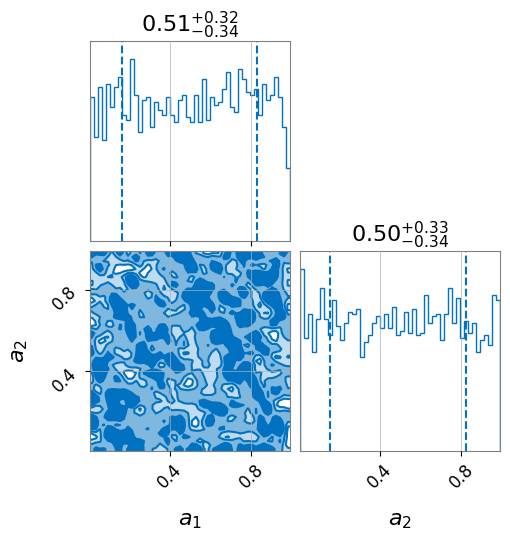

In [ ]:
nlive = 1000          # live points
stop = 0.1            # stopping criterion(change in log of posterior probability)
method = "unif"       # method of sampling
sampler = "dynesty"   # sampler to use

result = bilby.run_sampler(
    likelihood, prior, sampler=sampler, outdir=outdir, label=label,
    conversion_function=bilby.gw.conversion.generate_all_bbh_parameters,
    sample=method, nlive=nlive, dlogz=stop)

result.plot_corner()

In [ ]:
posts = result.posterior
#posts = pd.read_csv("/content/drive/My Drive/Results/GW190425_result.json", sep = " ")

chirp_mass_samps = list(posts["chirp_mass"])
mass_ratio_samps = list(posts["mass_ratio"])
geocent_time_samps = list(posts["geocent_time"])

chirp_mass, chirp_mass_err = np.mean(chirp_mass_samps), np.std(chirp_mass_samps)
mass_ratio, mass_ratio_err = np.mean(mass_ratio_samps), np.std(mass_ratio_samps)
geocent_time, geocent_time_err = np.mean(geocent_time_samps), np.std(geocent_time_samps)

print("Parameters describing the GW190425 signal: \n \n" +
      "  chirp mass = {}   \u00B1 {} \n".format(chirp_mass, chirp_mass_err) +
      "  mass ratio = {} \u00B1 {} \n \n".format(mass_ratio, mass_ratio_err) +
      "geocent time = {} \u00B1 {} \n".format(geocent_time, geocent_time_err) +
      "True geocent time = 1126259462.4")

In [ ]:
def bbhMass(chirp,chirperr,ratio,ratioerr):
    """
    Function that calculates black hole masses with errors

    m1,m2 = larger black hole mass, smaller black hole mass
    chirp = (m1*m2)**(3/5) / (m1+m2)**(1/5)
    ratio = m2/m1
    """

    # use chirp mass and ratio to find primary black hole mass
    m1 = chirp / (ratio**(3/5) * (1/(1+ratio))**(1/5))
    m1err = (chirp + chirperr) / ((ratio-ratioerr)**(3/5) *
                                  (1/(1+(ratio+ratioerr))**(1/5))) - m1

    # use primary black hole mass and ratio to find secondary black hole mass
    m2 = m1*ratio
    m2err = (m1+m1err)*(ratio+ratioerr) - m2

    return (m1,m1err),(m2,m2err)

(m1,m1err), (m2,m2err) = bbhMass(chirp_mass,chirp_mass_err,
                                 mass_ratio,mass_ratio_err)

print("Black hole masses from sampling (in solar masses): \n \n" +
      "   largest black hole = {} \u00B1 {} \n".format(m1, m1err) +
      "  smallest black hole = {} \u00B1 {} \n \n".format(m2, m2err) +
      "Accepted black hole masses (in solar masses): \n \n" +
      "   largest black hole = {}\n".format(36.2) +
      "  smallest black hole = {}".format(29.1))